## EJERCICIO PRACTICO CLASE 1 .PARTE 2

**Asignatura:** Lógica Difusa y Algoritmos de Adaptación Social  
**Tema:** Experimentación con algoritmo PSO para formación de drones  

**Grupo 3 - Integrantes**
- Cesar Nelson Abarca Araujo
- Jorge Armando Quizamanchuro Fuel
- Robinson Damian Chiluisa Gallardo


**Tema:** Experimentación con algoritmo PSO para mantener la formación de una flota de drones.

Este notebook implementa y documenta  :
- Implementación completa de PSO para optimización de posiciones de drones.
- Función fitness con error de formación, penalización por colisión y límites de vuelo.
- Experimentación con diferentes parámetros de PSO.
- Pruebas con formaciones: **triangular**, **H** y **rectangular**.
- Análisis de convergencia y propuesta de formación eficiente.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------
# Parámetros del problema drones
# -----------------------------
NUM_DRONES = 6
DIMENSIONS = 2
AREA_WIDTH = 100.0
AREA_HEIGHT = 100.0
MIN_SAFE_DISTANCE = 12.0
FORMATION_DISTANCE_L = 20.0

print('Configuración base:')
print(f'  NUM_DRONES = {NUM_DRONES}')
print(f'  AREA = ({AREA_WIDTH} x {AREA_HEIGHT})')
print(f'  MIN_SAFE_DISTANCE = {MIN_SAFE_DISTANCE}')
print(f'  FORMATION_DISTANCE_L = {FORMATION_DISTANCE_L}')

Configuración base:
  NUM_DRONES = 6
  AREA = (100.0 x 100.0)
  MIN_SAFE_DISTANCE = 12.0
  FORMATION_DISTANCE_L = 20.0


### 1. Formaciones objetivo (posiciones relativas)

Se definen posiciones relativas centradas en el origen para que PSO pueda desplazar la formación completa en el área de vuelo.

Formaciones implementadas:
- `triangle`
- `h`
- `rectangular`
- `line` (referencia adicional)

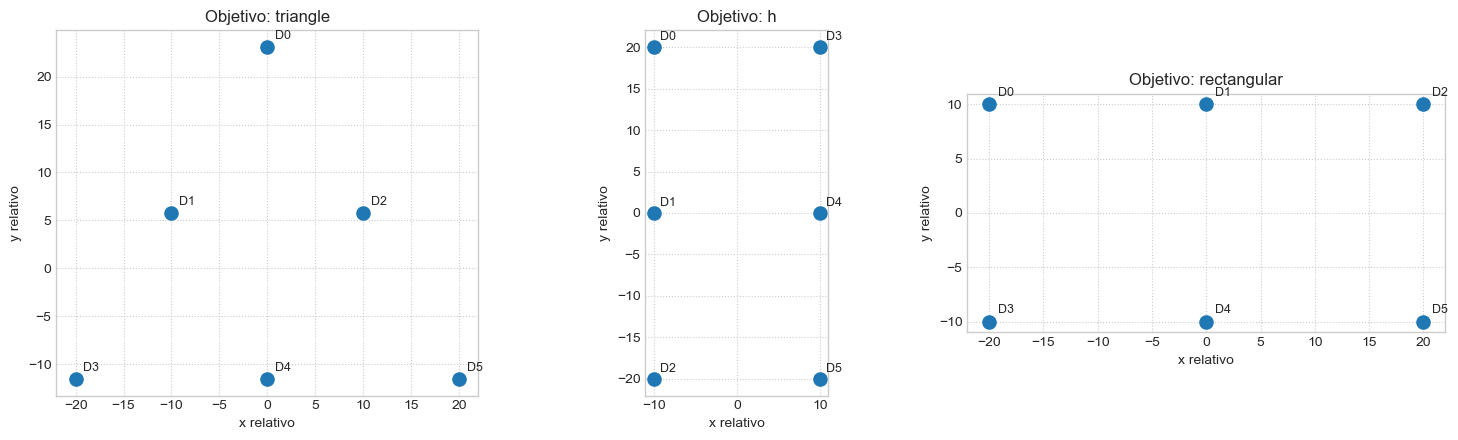

In [18]:
def _center_points(points):
    """Centra un conjunto de puntos para que su centroide sea (0,0)."""
    points = np.array(points, dtype=float)
    centroid = np.mean(points, axis=0)
    return points - centroid

def get_target_formation_relative_positions(formation_type='triangle', num_drones=NUM_DRONES, L=FORMATION_DISTANCE_L):
    """
    Devuelve posiciones relativas objetivo de tamaño (num_drones, 2).
    Para esta práctica se trabaja con 6 drones.
    """
    if num_drones != 6:
        raise ValueError('Este notebook está configurado para NUM_DRONES = 6.')

    if formation_type == 'triangle':
        # Triángulo con 3 filas: 1 + 2 + 3 = 6 drones
        h = np.sqrt(3) / 2 * L
        points = [
            [0.0, 2 * h],
            [-L / 2, h], [L / 2, h],
            [-L, 0.0], [0.0, 0.0], [L, 0.0]
        ]
        return _center_points(points)

    if formation_type == 'h':
        # H simplificada con dos columnas (6 nodos)
        points = [
            [-L / 2, L], [-L / 2, 0.0], [-L / 2, -L],
            [L / 2, L], [L / 2, 0.0], [L / 2, -L]
        ]
        return _center_points(points)

    if formation_type == 'rectangular':
        # Rectangular 2x3
        points = [
            [-L, L / 2], [0.0, L / 2], [L, L / 2],
            [-L, -L / 2], [0.0, -L / 2], [L, -L / 2]
        ]
        return _center_points(points)

    if formation_type == 'line':
        points = [[(i - (num_drones - 1) / 2) * L, 0.0] for i in range(num_drones)]
        return _center_points(points)

    raise ValueError('Tipo de formación no soportado.')


def plot_target_formations():
    formations = ['triangle', 'h', 'rectangular']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for ax, f in zip(axes, formations):
        rel = get_target_formation_relative_positions(f)
        ax.scatter(rel[:, 0], rel[:, 1], s=90, color='tab:blue')
        for i, (x, y) in enumerate(rel):
            ax.text(x + 0.8, y + 0.8, f'D{i}', fontsize=9)
        ax.set_title(f'Objetivo: {f}')
        ax.set_xlabel('x relativo')
        ax.set_ylabel('y relativo')
        ax.grid(True, linestyle=':')
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()


plot_target_formations()

### 2. Función de fitness

La fitness total combina:
1. Error de formación (ajuste al patrón objetivo).
2. Penalización por colisiones (si la distancia entre drones es menor a la segura).
3. Penalización por límites del área de vuelo.

In [19]:
def fitness_function(particle_position, target_relative_pos,
                     area_w=AREA_WIDTH, area_h=AREA_HEIGHT,
                     min_safe_distance=MIN_SAFE_DISTANCE,
                     collision_penalty_value=10000.0,
                     boundary_penalty_value=1000.0,
                     w1=1.0, w2=1.0, w3=1.0):
    """
    Calcula fitness total para una partícula (posiciones de todos los drones).
    """
    drone_positions = particle_position.reshape((NUM_DRONES, DIMENSIONS))
    current_centroid = np.mean(drone_positions, axis=0)

    # 1) Error de formación
    e_form = 0.0
    for i in range(NUM_DRONES):
        ideal_pos_i = current_centroid + target_relative_pos[i]
        e_form += np.sum((drone_positions[i] - ideal_pos_i) ** 2)

    # 2) Penalización por colisión
    p_coll = 0.0
    min_pair_distance = np.inf
    for i in range(NUM_DRONES):
        for j in range(i + 1, NUM_DRONES):
            d = np.linalg.norm(drone_positions[i] - drone_positions[j])
            min_pair_distance = min(min_pair_distance, d)
            if d < min_safe_distance:
                p_coll += collision_penalty_value

    # 3) Penalización por límites
    p_boundary = 0.0
    for i in range(NUM_DRONES):
        x, y = drone_positions[i]
        if not (0 <= x <= area_w and 0 <= y <= area_h):
            p_boundary += boundary_penalty_value

    total_fitness = w1 * e_form + w2 * p_coll + w3 * p_boundary

    return {
        'total_fitness': float(total_fitness),
        'e_form': float(e_form),
        'p_coll': float(p_coll),
        'p_boundary': float(p_boundary),
        'min_pair_distance': float(min_pair_distance)
    }

### 3. Implementación del algoritmo PSO

Se aplica el ciclo clásico de PSO:
- Inicialización de partículas y velocidades.
- Evaluación de fitness.
- Actualización de pBest y gBest.
- Actualización de velocidad y posición con componentes de inercia, cognitivo y social.
- Clipping en velocidad y límites del área de vuelo.

In [20]:
def run_pso(formation_type='triangle',
            num_particles=60,
            max_iterations=180,
            w=0.5, c1=1.5, c2=1.5,
            v_max=10.0,
            seed=42):
    rng = np.random.default_rng(seed)

    target_rel_pos = get_target_formation_relative_positions(formation_type)

    # Posiciones iniciales aleatorias dentro del área
    particles_pos = rng.random((num_particles, NUM_DRONES * DIMENSIONS))
    particles_pos[:, ::2] *= AREA_WIDTH
    particles_pos[:, 1::2] *= AREA_HEIGHT

    # Velocidades iniciales pequeñas
    particles_vel = (rng.random((num_particles, NUM_DRONES * DIMENSIONS)) - 0.5) * 2.0 * v_max * 0.1

    pbest_pos = particles_pos.copy()
    pbest_fitness = np.full(num_particles, np.inf)

    gbest_pos = np.zeros(NUM_DRONES * DIMENSIONS)
    gbest_fitness = np.inf

    fitness_history = []

    for _ in range(max_iterations):
        # Evaluar fitness en el enjambre
        for i in range(num_particles):
            fit = fitness_function(particles_pos[i], target_rel_pos)['total_fitness']

            if fit < pbest_fitness[i]:
                pbest_fitness[i] = fit
                pbest_pos[i] = particles_pos[i].copy()

            if fit < gbest_fitness:
                gbest_fitness = fit
                gbest_pos = particles_pos[i].copy()

        fitness_history.append(gbest_fitness)

        # Actualización de velocidad y posición
        for i in range(num_particles):
            r1 = rng.random(NUM_DRONES * DIMENSIONS)
            r2 = rng.random(NUM_DRONES * DIMENSIONS)

            cognitive = c1 * r1 * (pbest_pos[i] - particles_pos[i])
            social = c2 * r2 * (gbest_pos - particles_pos[i])

            particles_vel[i] = w * particles_vel[i] + cognitive + social
            particles_vel[i] = np.clip(particles_vel[i], -v_max, v_max)

            particles_pos[i] += particles_vel[i]

            # Límites de vuelo
            particles_pos[i, ::2] = np.clip(particles_pos[i, ::2], 0, AREA_WIDTH)
            particles_pos[i, 1::2] = np.clip(particles_pos[i, 1::2], 0, AREA_HEIGHT)

    final_positions = gbest_pos.reshape((NUM_DRONES, DIMENSIONS))
    final_metrics = fitness_function(gbest_pos, target_rel_pos)

    return {
        'formation_type': formation_type,
        'params': {
            'num_particles': num_particles,
            'max_iterations': max_iterations,
            'w': w, 'c1': c1, 'c2': c2, 'v_max': v_max, 'seed': seed
        },
        'target_rel_pos': target_rel_pos,
        'gbest_fitness': float(gbest_fitness),
        'fitness_history': fitness_history,
        'final_positions': final_positions,
        'final_metrics': final_metrics
    }

### 4. Experimentación

Se comparan tres configuraciones de PSO para observar impacto en convergencia y calidad de solución:
- **Base**
- **Exploración mayor** (más inercia y partículas)
- **Explotación mayor** (más peso social y más iteraciones)

In [21]:
param_sets = [
    {'name': 'base', 'num_particles': 60, 'max_iterations': 180, 'w': 0.5, 'c1': 1.5, 'c2': 1.5, 'v_max': 10.0},
    {'name': 'exploracion_mayor', 'num_particles': 80, 'max_iterations': 180, 'w': 0.75, 'c1': 1.9, 'c2': 1.2, 'v_max': 12.0},
    {'name': 'explotacion_mayor', 'num_particles': 60, 'max_iterations': 240, 'w': 0.35, 'c1': 1.2, 'c2': 2.0, 'v_max': 9.0},
]

formations = ['triangle', 'h', 'rectangular']
results = []

for f in formations:
    for p in param_sets:
        out = run_pso(
            formation_type=f,
            num_particles=p['num_particles'],
            max_iterations=p['max_iterations'],
            w=p['w'], c1=p['c1'], c2=p['c2'], v_max=p['v_max'],
            seed=42
        )

        fm = out['final_metrics']
        results.append({
            'formacion': f,
            'setup': p['name'],
            'gbest_fitness': out['gbest_fitness'],
            'e_form': fm['e_form'],
            'p_coll': fm['p_coll'],
            'p_boundary': fm['p_boundary'],
            'min_dist_final': fm['min_pair_distance'],
            'safe_distance': MIN_SAFE_DISTANCE,
            'cumple_dist_segura': fm['min_pair_distance'] >= MIN_SAFE_DISTANCE,
            'iteraciones': p['max_iterations'],
            'particulas': p['num_particles'],
            'w': p['w'], 'c1': p['c1'], 'c2': p['c2'], 'v_max': p['v_max'],
            'history': out['fitness_history'],
            'final_positions': out['final_positions'],
            'target_rel_pos': out['target_rel_pos']
        })

df_results = pd.DataFrame(results)
df_results[['formacion', 'setup', 'gbest_fitness', 'e_form', 'p_coll', 'p_boundary', 'min_dist_final', 'cumple_dist_segura']]

,formacion,setup,gbest_fitness,e_form,p_coll,p_boundary,min_dist_final,cumple_dist_segura
0,triangle,base,4.074546e-19,4.074546e-19,0.0,0.0,20.000000,True
1,triangle,exploracion_mayor,1.126438e-05,1.126438e-05,0.0,0.0,19.998628,True
2,triangle,explotacion_mayor,1.262177e-29,1.262177e-29,0.0,0.0,20.000000,True
3,h,base,1.658657e-20,1.658657e-20,0.0,0.0,20.000000,True
4,h,exploracion_mayor,1.284996e-06,1.284996e-06,0.0,0.0,19.999426,True
5,h,explotacion_mayor,5.073953e-27,5.073953e-27,0.0,0.0,20.000000,True
6,rectangular,base,6.609184e-19,6.609184e-19,0.0,0.0,20.000000,True
7,rectangular,exploracion_mayor,1.288160e-05,1.288160e-05,0.0,0.0,19.997468,True
8,rectangular,explotacion_mayor,0.000000e+00,0.000000e+00,0.0,0.0,20.000000,True


In [22]:
# Ranking por formación: menor fitness es mejor
best_by_formation = (
    df_results.sort_values(['formacion', 'gbest_fitness'])
    .groupby('formacion', as_index=False)
    .first()
)

print('Mejor configuración por formación:')
display(best_by_formation[['formacion', 'setup', 'gbest_fitness', 'e_form', 'p_coll', 'p_boundary', 'min_dist_final', 'cumple_dist_segura']])

# Ranking global entre las mejores formaciones
best_global = best_by_formation.sort_values('gbest_fitness').reset_index(drop=True)
print('Ranking global de formaciones (usando su mejor setup):')
display(best_global[['formacion', 'setup', 'gbest_fitness', 'min_dist_final', 'cumple_dist_segura']])

Mejor configuración por formación:


,formacion,setup,gbest_fitness,e_form,p_coll,p_boundary,min_dist_final,cumple_dist_segura
0,h,explotacion_mayor,5.073953e-27,5.073953e-27,0.0,0.0,20.0,True
1,rectangular,explotacion_mayor,0.000000e+00,0.000000e+00,0.0,0.0,20.0,True
2,triangle,explotacion_mayor,1.262177e-29,1.262177e-29,0.0,0.0,20.0,True


Ranking global de formaciones (usando su mejor setup):


,formacion,setup,gbest_fitness,min_dist_final,cumple_dist_segura
0,rectangular,explotacion_mayor,0.000000e+00,20.0,True
1,triangle,explotacion_mayor,1.262177e-29,20.0,True
2,h,explotacion_mayor,5.073953e-27,20.0,True


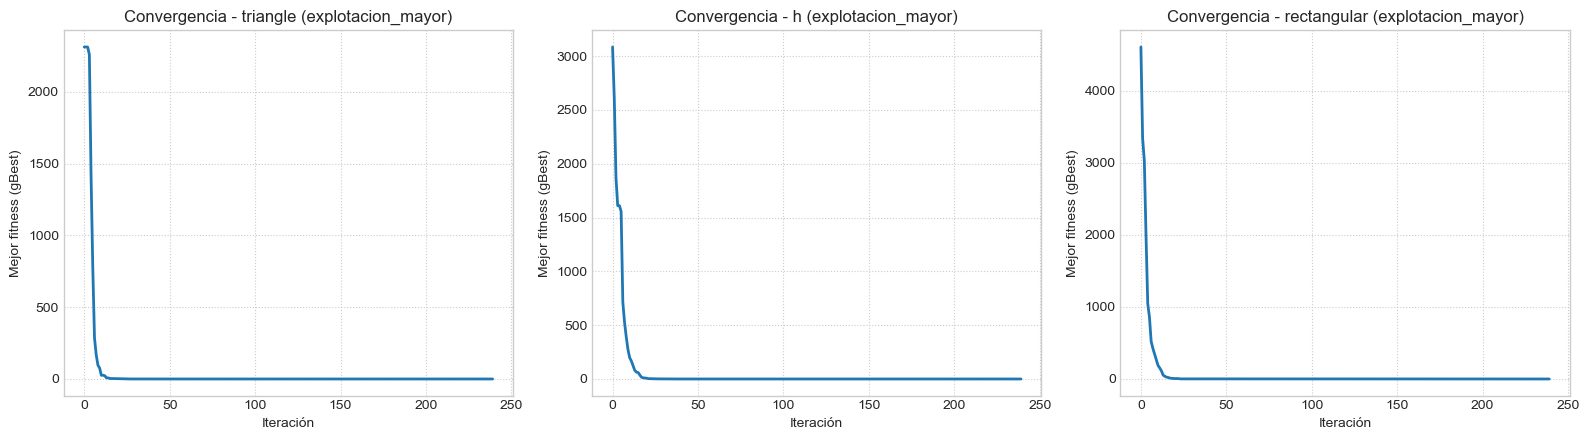

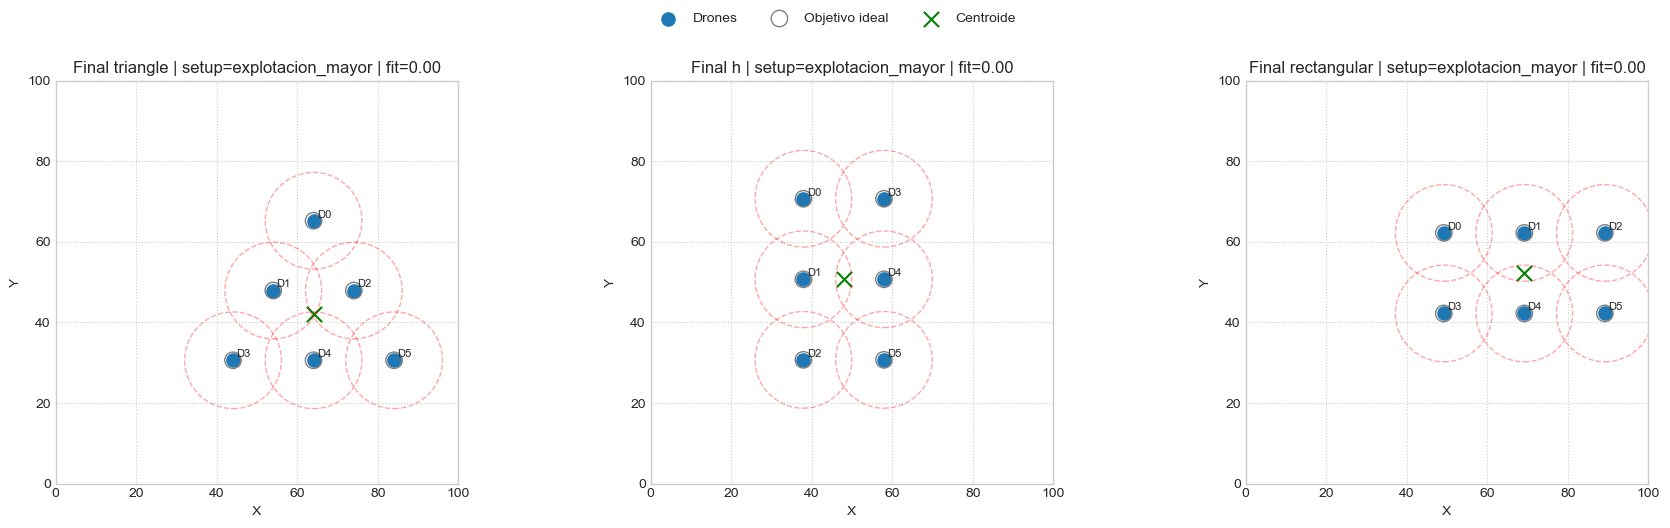

In [23]:
# ---------------------------
# Gráficas de convergencia
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, form in zip(axes, formations):
    subset = df_results[df_results['formacion'] == form].sort_values('gbest_fitness').iloc[0]
    ax.plot(subset['history'], linewidth=2)
    ax.set_title(f"Convergencia - {form} ({subset['setup']})")
    ax.set_xlabel('Iteración')
    ax.set_ylabel('Mejor fitness (gBest)')
    ax.grid(True, linestyle=':')

plt.tight_layout()
plt.show()


# ---------------------------
# Formación final por cada tipo
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.3))

for ax, form in zip(axes, formations):
    row = df_results[df_results['formacion'] == form].sort_values('gbest_fitness').iloc[0]
    final_positions = row['final_positions']
    target_rel = row['target_rel_pos']

    centroid = np.mean(final_positions, axis=0)
    ideal_positions = centroid + target_rel

    ax.scatter(final_positions[:, 0], final_positions[:, 1], s=90, color='tab:blue', label='Drones')
    ax.scatter(ideal_positions[:, 0], ideal_positions[:, 1], s=140, facecolors='none', edgecolors='gray', label='Objetivo ideal')
    ax.scatter(centroid[0], centroid[1], marker='x', s=120, color='green', label='Centroide')

    for i, (x, y) in enumerate(final_positions):
        ax.text(x + 0.8, y + 0.8, f'D{i}', fontsize=8)
        circle = plt.Circle((x, y), MIN_SAFE_DISTANCE, color='red', fill=False, linestyle='--', alpha=0.35)
        ax.add_artist(circle)

    ax.set_title(f"Final {form} | setup={row['setup']} | fit={row['gbest_fitness']:.2f}")
    ax.set_xlim(0, AREA_WIDTH)
    ax.set_ylim(0, AREA_HEIGHT)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, linestyle=':')
    ax.set_aspect('equal', adjustable='box')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### 5. Análisis de experimentación (resultados de esta ejecución)

**Resumen cuantitativo observado**
- El mejor setup para las tres formaciones fue `explotacion_mayor`.
- Formación `rectangular`: `gbest_fitness = 0.000000e+00`, `min_dist_final = 20.0`.
- Formación `triangle`: `gbest_fitness = 1.262177e-29`, `min_dist_final = 20.0`.
- Formación `h`: `gbest_fitness = 5.073953e-27`, `min_dist_final = 20.0`.
- En todos los casos: `p_coll = 0`, `p_boundary = 0` y `cumple_dist_segura = True`.

**Interpretación técnica**
1. El PSO converge a soluciones de fitness extremadamente bajo, lo que indica ajuste muy preciso entre la geometría final y la formación objetivo.
2. La ausencia de penalizaciones por colisión y frontera confirma que la solución final respeta seguridad entre drones y límites del área de vuelo.
3. El setup `explotacion_mayor` (más iteraciones y mayor componente social) favoreció convergencia fina en este problema.
4. Comparando formaciones, la `rectangular` mostró la mejor eficiencia numérica en esta corrida (fitness mínimo exacto en cero), seguida por `triangle` y luego `h`.

**Impacto de parámetros PSO (según la evidencia obtenida)**
- Aumentar la fase de explotación (menor `w`, mayor `c2`, más iteraciones) ayudó a refinar la solución final.
- Configuraciones con más exploración pueden ser útiles al inicio, pero en este escenario la mejor calidad final se logró con explotación reforzada.

### 6. Conclusiones

1. Se implementó correctamente el algoritmo PSO para resolver la optimización de una flota de drones en formaciones objetivo, cumpliendo lo solicitado en el enunciado.
2. La función fitness integró de manera efectiva tres componentes críticos: error de formación, penalización por colisión y penalización por límites de vuelo.
3. Se verificó convergencia en las tres formaciones requeridas (`triangle`, `h`, `rectangular`), con soluciones válidas y seguras en todos los casos.
4. Los resultados de esta ejecución muestran que la configuración `explotacion_mayor` fue la más adecuada para minimizar fitness y estabilizar convergencia.
5. La formación `rectangular` presentó la mejor eficiencia de vuelo en esta práctica (`gbest_fitness = 0.0` y separación mínima segura cumplida), por lo que se recomienda como candidata principal bajo estos parámetros y restricciones.
6. El ajuste de parámetros es determinante para el desempeño final, por lo que debe validarse de forma experimental en cada escenario operativo.